In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from scipy.integrate import odeint, quad
from scipy.optimize import minimize_scalar
from scipy.interpolate import interp1d
import statsmodels.api as sm

In [31]:
df_d = pd.read_csv("Dutch_paydiff_norm_zerocost.csv")
df_h = pd.read_csv("Honolulu_paydiff_norm_zerocost.csv")
df_d = df_d[df_d["subsession.round_number"] > 2]
df_h = df_h[df_h["subsession.round_number"] > 2]

In [32]:
df_d["is_5_bidder"] = df_d["session.config.name"].str.contains("5_")
df_d["mid_paydiff"] = df_d.apply(
    lambda x: np.median(
        df_d[(df_d["is_5_bidder"] == x["is_5_bidder"]) & (df_d["session.config.discount_b"] == x["session.config.discount_b"])]["paydiff_pct"].unique()
    ), 
    axis=1,
)
df_d["is_top"] = (df_d["paydiff_pct"] > df_d["mid_paydiff"])

df_h["is_5_bidder"] = df_h["session.config.name"].str.contains("5_")
df_h["mid_paydiff"] = df_h.apply(
    lambda x: np.median(
        df_h[(df_h["is_5_bidder"] == x["is_5_bidder"]) & (df_h["session.config.discount_b"] == x["session.config.discount_b"])]["paydiff_pct"].unique()
    ), 
    axis=1,
)
df_h["is_top"] = (df_h["paydiff_pct"] > df_h["mid_paydiff"])

In [33]:
dict_d = {
    (2, 0.019): dict(),
    (2, 0.009): dict(),
    (5, 0.019): dict(),
    (5, 0.009): dict(),
}

for index, row in df_d.iterrows():

    n = int(row["session.config.name"][1])
    b = row["session.config.discount_b"]
    key1 = (n, b)

    code = row["session.code"]
    round = row["subsession.round_number"]
    group = row["group.id_in_subsession"]
    key2 = (code, round, group)

    have_winner = row["group.have_dutch_winner"]
    is_winner = row["player.is_dutch_winner"]
    final_price = row["group.dutch_final_price"]
    duration = row["group.dutch_time_elapsed"]

    pred_is_winner = row["predict.player.is_dutch_winner"]
    pred0_is_winner = row["predict0.player.is_dutch_winner"]

    if key2 not in dict_d[key1].keys():
        dict_d[key1][key2] = {
            "have_winner": have_winner,
            "final_price": final_price,
            "duration": duration,
            "ua": row["group.auctioneer_utility"],
            "pred_final_price": row["predict.group.dutch_final_price"],
            "pred_duration": row["predict.group.dutch_time_elapsed"],
            "pred_ua": row["predict.group.auctioneer_utility"],
            "pred0_final_price": row["predict0.group.dutch_final_price"],
            "pred0_duration": row["predict0.group.dutch_time_elapsed"],
            "pred0_ua": row["predict0.group.auctioneer_utility"],
        }

    if is_winner:
        diff = row["player.item_value"] - final_price
        if diff >= 0:
            dict_d[key1][key2]["ub"] = diff * (1 - b * duration)
        else:
            dict_d[key1][key2]["ub"] = diff * (1 + b * duration)
        dict_d[key1][key2]["ub_rounded"] = row["player.payoff"]

    if pred_is_winner:
        dict_d[key1][key2]["pred_ub"] = row["predict.player.payoff"]

    if pred0_is_winner:
        dict_d[key1][key2]["pred0_ub"] = row["predict0.player.payoff"]
    
    if is_winner:
        max_value = np.max(df_d[(df_d["session.code"] == code) & (df_d["subsession.round_number"] == round) & (df_d["group.id_in_subsession"] == group)]["player.item_value"])
        dict_d[key1][key2]["efficiency"] = row["player.item_value"] / max_value * 100
    elif not have_winner:
        dict_d[key1][key2]["efficiency"] = 0

In [34]:
dict_h = {
    (2, 0.019): dict(),
    (2, 0.009): dict(),
    (5, 0.019): dict(),
    (5, 0.009): dict(),
}

for index, row in df_h.iterrows():

    n = int(row["session.config.name"][1])
    b = row["session.config.discount_b"]
    key1 = (n, b)

    code = row["session.code"]
    round = row["subsession.round_number"]
    group = row["group.id_in_subsession"]
    key2 = (code, round, group)

    have_winner = row["group.have_contest_winner"]
    is_winner = row["player.is_final_winner"]
    final_price = row["group.final_price"]
    duration = row["group.dutch_time_elapsed"] + row["group.english_time_elapsed"]

    pred_is_winner = row["predict.player.is_final_winner"]
    pred0_is_winner = row["predict0.player.is_final_winner"]

    if key2 not in dict_h[key1].keys():
        dict_h[key1][key2] = {
            "have_winner": have_winner,
            "final_price": final_price,
            "duration": duration,
            "ua": row["group.auctioneer_utility"],
            "pred_final_price": row["predict.group.final_price"],
            "pred_duration": row["predict.group.dutch_time_elapsed"] + row["predict.group.english_time_elapsed"],
            "pred_ua": row["predict.group.auctioneer_utility"],
            "pred0_final_price": row["predict0.group.final_price"],
            "pred0_duration": row["predict0.group.dutch_time_elapsed"] + row["predict0.group.english_time_elapsed"],
            "pred0_ua": row["predict0.group.auctioneer_utility"],
        }

    if is_winner:
        diff = row["player.item_value"] - final_price
        if diff >= 0:
            dict_h[key1][key2]["ub"] = (row["player.item_value"] - final_price) * (1 - b * duration)
        else:
            dict_h[key1][key2]["ub"] = (row["player.item_value"] - final_price) * (1 + b * duration)
        dict_h[key1][key2]["ub_rounded"] = row["player.payoff"]
        
    if pred_is_winner:
        dict_h[key1][key2]["pred_ub"] = row["predict.player.payoff"]

    if pred0_is_winner:
        dict_h[key1][key2]["pred0_ub"] = row["predict0.player.payoff"]
    
    if is_winner:
        max_value = np.max(df_h[(df_h["session.code"] == code) & (df_h["subsession.round_number"] == round) & (df_h["group.id_in_subsession"] == group)]["player.item_value"])
        dict_h[key1][key2]["efficiency"] = row["player.item_value"] / max_value * 100
    elif not have_winner:
        dict_h[key1][key2]["efficiency"] = 0

In [35]:
class honolulu(object):
    def __init__(self, a, b, c, n):
        self.n = n
        self.a = a
        self.b = b
        self.c = c
        if c == 0:
            self.s = 1
        else:
            self.s = self.max_U()

    # F(x) = x
    # G(x) = F(x) ^ (n - 1)
    # g(x) = G'(x)
    # H(x) = integral(y[0, x])(G(y))
    # G(v, x) = n * F(v) * F(x) ^ (n - 1)
    # g(v, x) = d^2 G(v, x) / dvdx

    def K(self, pvar, v, s):
        # K(p, v, s) = 2 * b * (H(v) - H(p)) - G(p) * (a - b * (s - v))
        return (
            2 * self.b 
            * (v ** self.n - pvar ** self.n) / self.n 
            - pvar ** (self.n - 1) 
            * (self.a - self.b * (s - v))
        )

    def k(self, v, s):
        # p = k(v, s) solves K(p, v, s) = 0
        K_fun = lambda pvar: self.K(pvar, v, s)
        sol = fsolve(K_fun, v / 2)[0]
        return sol

    def p(self, v, s):
        # p = min{s, k(v, s)}
        return np.minimum(s, self.k(v, s))

    def U(self, s):
        # integral(x[0, p(v, s)], v[0, 1])(p(v, s) * (a - c * (s - p(v, s))) * g(v, x)) + 
        # integral(x[p(v, s), v], v[0, 1])(x * (a - c * (s + x - 2 * p(v, s))) * g(v, x)) 
        # double integration is too slow, manually compute the integration with respect to x first
        integrand = (
            lambda v: (self.n - 1) * v ** self.n * (self.a - self.c * (s - 2 * self.p(v, s)))
            - self.n * (self.n - 1) / (self.n + 1) * self.c * v ** (self.n + 1)
            + self.p(v, s) ** self.n * (self.a - self.c * s + 2 * self.c * self.p(v, s) / (self.n + 1))
        )
        sol = quad(integrand, 0, 1)[0]
        return sol

    def max_U(self):
        obj_fun = lambda s: - self.U(s)
        sol = minimize_scalar(obj_fun, bounds=(0, 1), method="bounded")
        return sol["x"]
    
    def EUa(self):
        return self.U(self.s)

    def ER(self):
        # integral(x[0, p(v, s)], v[0, 1])(p(v, s) * g(v, x)) + 
        # integral(x[p(v, s), v], v[0, 1])(x * g(v, x))
        # double integration is too slow, manually compute the integration with respect to x first
        integrand = (
            lambda v: self.p(v, self.s) ** self.n
            + (self.n - 1) * v ** self.n
        )
        sol = quad(integrand, 0, 1)[0]
        return sol

    def ED(self):
        # integral(x[0, p(v, s)], v[0, 1])((s - p(v, s)) * g(v, x)) + 
        # integral(x[p(v, s), v], v[0, 1])((s + x - 2 * p(v, s)) * g(v, x))
        # double integration is too slow, manually compute the integration with respect to x first
        integrand = (
            lambda v: self.p(v, self.s) ** self.n
            + (self.n - 1) * v ** self.n
            + self.n * (self.s - 2 * self.p(v, self.s)) * v ** (self.n - 1)
        )
        sol = quad(integrand, 0, 1)[0]
        return sol
    
    def eUb(self, v):
        # G(p(v, s)) * (v - p(v, s)) * (a - b * (s - p(v, s))) +
        # integral(x[p(v, s), v])((v - x) * (a -  b * (s + x - 2 * p(v, s))) * g(x))
        integrand = (
            lambda x: (v - x)
            * (self.a - self.b * (self.s + x - 2 * self.p(v, self.s)))
            * (self.n - 1) * x ** (self.n - 2)
        )
        return (
            self.p(v, self.s) ** (self.n - 1)
            * (v - self.p(v, self.s))
            * (self.a - self.b * (self.s - self.p(v, self.s)))
            + quad(integrand, self.p(v, self.s), v)[0]
        )

    def EUb(self):
        integrand = lambda v: self.eUb(v)
        return quad(integrand, 0, 1)[0]

    def ePb(self, v):
        # p(v, s) ^ n + integral(x[p(v, s), v])(x * g(x))
        integrand = lambda x: x * (self.n - 1) * x ** (self.n - 2)
        return self.p(v, self.s) ** self.n + quad(integrand, self.p(v, self.s), v)[0]

In [36]:
class dutch(object):
    def __init__(self, a, b, c, n):
        self.a = a
        self.b = b
        self.c = c
        self.n = n
        self.vs = np.linspace(1e-16, 1, 10000)

    # F(x) = x
    # G(x) = F(x) ^ (n - 1)
    # g(x) = G'(x)
    # H(x) = F(x) ^ n
    # h(x) = H'(x)

    def db_dv(self, beta, v):
        # beta'(v) = g(v)* (v - beta(v)) * (a - b * (1 - beta(v))) / (G(v) * (a + 2 * b * beta(v) - b - b * v))
        return (
            (self.n - 1) * v ** (self.n - 2)
            * (v - beta)
            * (self.a - self.b * (1 - beta))
            / (v ** (self.n - 1) * (self.a + 2 * self.b * beta - self.b - self.b * v))
        )

    def solve_ode(self):
        beta0 = 0
        return odeint(self.db_dv, beta0, self.vs).flatten()

    def beta(self, v):
        return interp1d(self.vs, self.solve_ode(), fill_value="extrapolate")(v)

    def EUa(self):
        # integral(v[0, 1])(beta(v) * (a - c * (1 - beta(v))) * h(v))
        integrand = (
            lambda v: self.beta(v)
            * (self.a - self.c * (1 - self.beta(v)))
            * self.n * v ** (self.n - 1)
        )
        return quad(integrand, 0, 1)[0]

    def ER(self):
        # integral(v[0, 1])(beta(v) * h(v))
        integrand = lambda x: self.beta(x) * self.n * x ** (self.n - 1)
        return quad(integrand, 0, 1)[0]
    
    def ED(self):
        # 1- integral(v[0, 1])(beta(v) * h(v))
        integrand = lambda v: self.beta(v) * self.n * v ** (self.n - 1)
        return 1 - quad(integrand, 0, 1)[0]

    def eUb(self, v):
        # v ^ (n - 1) * (v - beta(v)) * (a - b * (1 - beta(v)))
        return (
            v ** (self.n - 1) * (v - self.beta(v)) * (self.a - self.b * (1 - self.beta(v)))
        )
    
    def EUb(self):
        integrand = lambda v: self.eUb(v)
        return quad(integrand, 0, 1)[0]

    def ePb(self, v):
        # v ^ (n - 1) * beta(v)
        return v ** (self.n - 1) * self.beta(v)

### carryover effects by treatment

In [ ]:
# dutch auction bid deviations by treatment
def carryoverDutchDeviation(n, dfirst):
    tmp = df_d[(df_d["session.config.name"].str.contains(str(n) + "_")) & (df_d["session.config.name"].str.contains(dfirst)) & (df_d["player.is_dutch_winner"] == 1)]
    tmp_h = tmp[tmp["session.config.discount_b"] == 0.019]
    tmp_l = tmp[tmp["session.config.discount_b"] == 0.009]

    act = tmp["group.dutch_final_price"]
    pre = tmp["predict.player.bid"]
    act_h = tmp_h["group.dutch_final_price"]
    pre_h = tmp_h["predict.player.bid"]
    act_l = tmp_l["group.dutch_final_price"]
    pre_l = tmp_l["predict.player.bid"]

    print([n, dfirst])
    print("pooled\tH\tL")
    print("%.2f\t%.2f\t%.2f" % (np.mean(act) - np.mean(pre), np.mean(act_h) - np.mean(pre_h), np.mean(act_l) - np.mean(pre_l)))
    print("")

In [8]:
carryoverDutchDeviation(2, "D1")
carryoverDutchDeviation(2, "D2")
carryoverDutchDeviation(5, "D1")
carryoverDutchDeviation(5, "D2")

[2, 'D1']
pooled	H	L
2.30	0.12	4.00

[2, 'D2']
pooled	H	L
0.99	-0.53	3.45

[5, 'D1']
pooled	H	L
4.41	1.89	6.80

[5, 'D2']
pooled	H	L
3.12	2.84	3.46



In [ ]:
# dutch stage bid deviations by treatment

def carryoverDutchStageDeviation(n, dfirst):
    tmp = df_h[(df_h["session.config.name"].str.contains(str(n) + "_")) & (df_h["session.config.name"].str.contains(dfirst)) & (df_h["player.is_dutch_winner"] == 1)]
    tmp_h = tmp[tmp["session.config.discount_b"] == 0.019]
    tmp_l = tmp[tmp["session.config.discount_b"] == 0.009]

    act = tmp["group.dutch_final_price"]
    pre = tmp["predict.player.optimal_dutch_bid"]
    act_h = tmp_h["group.dutch_final_price"]
    pre_h = tmp_h["predict.player.optimal_dutch_bid"]
    act_l = tmp_l["group.dutch_final_price"]
    pre_l = tmp_l["predict.player.optimal_dutch_bid"]

    print([n, dfirst])
    print("pooled\tH\tL")
    print("%.2f\t%.2f\t%.2f" % (np.mean(act) - np.mean(pre), np.mean(act_h) - np.mean(pre_h), np.mean(act_l) - np.mean(pre_l)))
    print("")


In [10]:
carryoverDutchStageDeviation(2, "D1")
carryoverDutchStageDeviation(2, "D2")
carryoverDutchStageDeviation(5, "D1")
carryoverDutchStageDeviation(5, "D2")

[2, 'D1']
pooled	H	L
-2.81	-4.20	-1.72

[2, 'D2']
pooled	H	L
-1.40	-1.51	-1.21

[5, 'D1']
pooled	H	L
-0.73	-1.08	-0.40

[5, 'D2']
pooled	H	L
1.04	1.12	0.95



In [56]:
# dutch final price deviations by treatment

def carryoverDutchFinalPriceDeviation(n, dfirst):
    cols = [
        "session.config.discount_b", "subsession.round_number", "group.id_in_subsession",
        "group.dutch_final_price", "predict.group.dutch_final_price"
    ]
    
    tmp = df_d[(df_d["session.config.name"].str.contains(str(n) + "_")) & (df_d["session.config.name"].str.contains(dfirst))][cols].drop_duplicates()
    tmp_h = tmp[tmp["session.config.discount_b"] == 0.019]
    tmp_l = tmp[tmp["session.config.discount_b"] == 0.009]

    act = tmp["group.dutch_final_price"]
    pre = tmp["predict.group.dutch_final_price"]
    act_h = tmp_h["group.dutch_final_price"]
    pre_h = tmp_h["predict.group.dutch_final_price"]
    act_l = tmp_l["group.dutch_final_price"]
    pre_l = tmp_l["predict.group.dutch_final_price"]

    print([n, dfirst])
    print("pooled\tH\tL")
    print("%.2f\t%.2f\t%.2f" % (np.mean(act) - np.mean(pre), np.mean(act_h) - np.mean(pre_h), np.mean(act_l) - np.mean(pre_l)))
    print("")

In [57]:
carryoverDutchFinalPriceDeviation(2, "D1")
carryoverDutchFinalPriceDeviation(2, "D2")
carryoverDutchFinalPriceDeviation(5, "D1")
carryoverDutchFinalPriceDeviation(5, "D2")

[2, 'D1']
pooled	H	L
1.72	-0.31	3.29

[2, 'D2']
pooled	H	L
0.10	-1.53	2.81

[5, 'D1']
pooled	H	L
3.07	1.28	4.76

[5, 'D2']
pooled	H	L
2.69	2.56	2.85



In [ ]:
# honolulu final price deviations by treatment

def carryoverHonoluluFinalPriceDeviation(n, dfirst):
    cols = [
        "session.config.discount_b", "subsession.round_number", "group.id_in_subsession",
        "group.final_price", "predict.group.final_price"
    ]
    
    tmp = df_h[(df_h["session.config.name"].str.contains(str(n) + "_")) & (df_h["session.config.name"].str.contains(dfirst))][cols].drop_duplicates()
    tmp_h = tmp[tmp["session.config.discount_b"] == 0.019]
    tmp_l = tmp[tmp["session.config.discount_b"] == 0.009]

    act = tmp["group.final_price"]
    pre = tmp["predict.group.final_price"]
    act_h = tmp_h["group.final_price"]
    pre_h = tmp_h["predict.group.final_price"]
    act_l = tmp_l["group.final_price"]
    pre_l = tmp_l["predict.group.final_price"]

    print([n, dfirst])
    print("pooled\tH\tL")
    print("%.2f\t%.2f\t%.2f" % (np.mean(act) - np.mean(pre), np.mean(act_h) - np.mean(pre_h), np.mean(act_l) - np.mean(pre_l)))
    print("")

In [ ]:
carryoverHonoluluFinalPriceDeviation(2, "D1")
carryoverHonoluluFinalPriceDeviation(2, "D2")
carryoverHonoluluFinalPriceDeviation(5, "D1")
carryoverHonoluluFinalPriceDeviation(5, "D2")

[2, 'D1']
pooled	H	L
-2.75	-2.91	-2.64

[2, 'D2']
pooled	H	L
-2.46	-2.57	-2.27

[5, 'D1']
pooled	H	L
-1.14	-0.52	-1.73

[5, 'D2']
pooled	H	L
-0.43	-0.54	-0.30



### carryover effects for top and bottom earners

In [37]:
# dutch auction bid deviations between top and bottom earners

def dutchDeviation(n, dfirst):
    tmp = df_d[(df_d["session.config.name"].str.contains(str(n) + "_"))]
    if (dfirst == "D1") or (dfirst == "D2"):
        tmp = tmp[tmp["session.config.name"].str.contains(dfirst)]
    tmp = tmp[tmp["player.is_dutch_winner"] == 1]

    act = tmp["group.dutch_final_price"]
    pre = tmp["predict.player.bid"]

    # drop outliers with 1/3 or more bids that bid > value + 2
    # plist = tmp["participant.code"].unique()
    # droplist = []
    # for p in plist:
    #     n_all = len(tmp[tmp["participant.code"] == p])
    #     n_sd = len(tmp[(tmp["participant.code"] == p) & (tmp["player.item_value"] + 2 < tmp["group.dutch_final_price"])])
    #     if (n_sd / n_all >= 1 / 3):
    #         droplist.append(p)
    # tmp = tmp[~tmp["participant.code"].isin(droplist)]
    # print(droplist)

    tmp_top = tmp[tmp["is_top"] == 1]
    tmp_bot = tmp[tmp["is_top"] == 0]

    act_top = tmp_top["group.dutch_final_price"]
    pre_top = tmp_top["predict.player.bid"]
    act_bot = tmp_bot["group.dutch_final_price"]
    pre_bot = tmp_bot["predict.player.bid"]

    return np.mean(act_top) - np.mean(pre_top), np.mean(act_bot) - np.mean(pre_bot), np.mean(act) - np.mean(pre)

In [42]:
def plotDbid(n):

    x = np.array([1, 2])
    wd = 0.2
    ybot = -6
    ytop = 15
    y1, y2, y3 = [], [], []
    for dfirst in ["D1", "D2"]:
        tmp1, tmp2, tmp3 = dutchDeviation(n, dfirst)
        y1.append(tmp1)
        y2.append(tmp2)
        y3.append(tmp3)
    plt.bar(x - 1 * wd, y1, width=wd, color="maroon", label="Top")
    plt.bar(x, y2, width=wd, edgecolor="darkolivegreen", fill=False, label="Bottom")
    plt.bar(x + 1 * wd, y3, width=wd, edgecolor="royalblue", fill=False, hatch="/", label="Pooled")
    plt.axhline(0, color="grey", linewidth=1, alpha=0.5)

    for a, b in zip(x, y1):
        if b >= 0:
            plt.text(a - 1 * wd, b + 0.3, "%.1f" % b, ha="center", color="black", fontsize="medium")
        else:
            plt.text(a - 1 * wd, b - 0.8, "%.1f" % b, ha="center", color="black", fontsize="medium")
    for a, b in zip(x, y2):
        if b >= 0:
            plt.text(a, b + 0.3, "%.1f" % b, ha="center", color="black", fontsize="medium")
        else:
            plt.text(a, b - 0.8, "%.1f" % b, ha="center", color="black", fontsize="medium")
    for a, b in zip(x, y3):
        if b >= 0:
            plt.text(a + 1 * wd, b + 0.3, "%.1f" % b, ha="center", color="black", fontsize="medium")
        else:
            plt.text(a + 1 * wd, b - 0.8, "%.1f" % b, ha="center", color="black", fontsize="medium")

    props = dict(
        connectionstyle = "bar, armA=0, armB=0, fraction=0.04",
        arrowstyle = "-",
        shrinkA = 0.5,
        shrinkB = 0.5,
        linewidth = 1,
    )
    p = 0.474 if n == 2 else 0.431
    plt.annotate("", (x[0] + 1 * wd, ytop - 2), (x[1] + 1 * wd, ytop - 2), arrowprops=props)
    plt.annotate("p=%.3f" % p, ((x[0] + x[1] + 2 * wd) / 2, ytop - 1), ha="center", fontsize="medium")
    # props = dict(
    #     connectionstyle = "bar, armA=0, armB=0, fraction=-0.04",
    #     arrowstyle = "-",
    #     shrinkA = 0.5,
    #     shrinkB = 0.5,
    #     linewidth = 1,
    # )
    ptop = 0.998 if n == 2 else 0.748
    plt.annotate("", (x[0] - 1 * wd, ytop - 4), (x[1] - 1 * wd, ytop - 4), arrowprops=props)
    plt.annotate("p=%.3f" % ptop, ((x[0] + x[1] - 2 * wd) / 2, ytop - 3), ha="center", fontsize="medium")
    pbot = 0.241 if n == 2 else 0.260
    plt.annotate("", (x[0], ytop - 6), (x[1], ytop - 6), arrowprops=props)
    plt.annotate("p=%.3f" % pbot, ((x[0] + x[1]) / 2, ytop - 5), ha="center", fontsize="medium")

    plt.ylim(ybot, ytop)
    plt.xticks(x, ["Dutch first", "Honolulu first"])
    plt.ylabel("Mean deviation, points")

    # plt.annotate("2 bidders", (1.5, ybot), (1.5, ybot-2.5), ha="center", fontsize="medium")
    # plt.annotate("5 bidders", (3.5, ybot), (3.5, ybot-2.5), ha="center", fontsize="medium")
    # plt.legend(ncol=2, loc="center", bbox_to_anchor=(0.5, -0.25))
    plt.title("%d bidders" % (n), pad=10, fontsize="large")

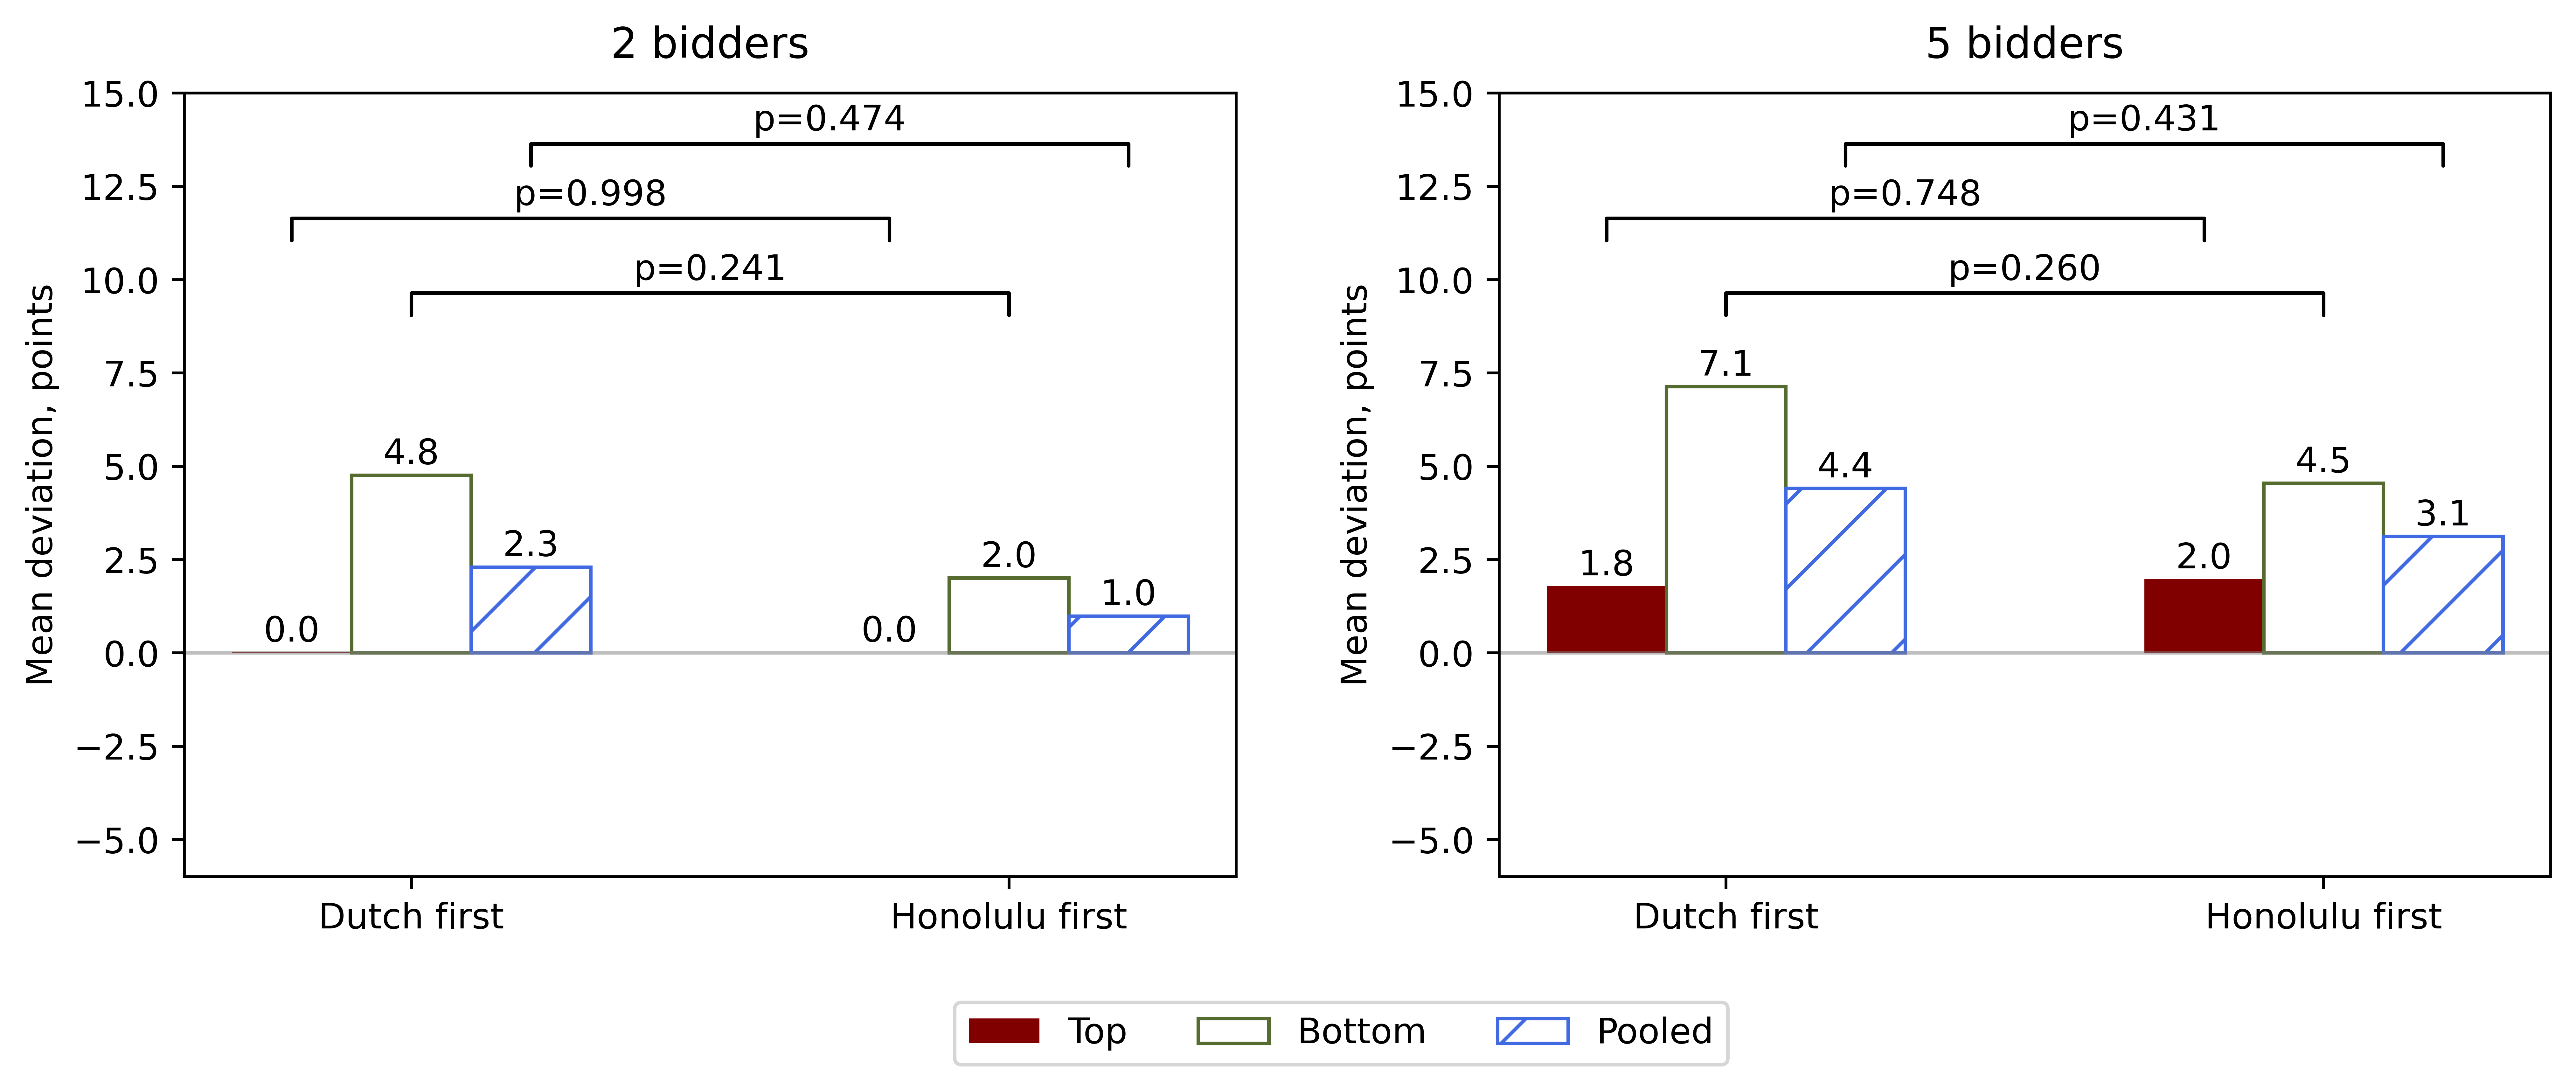

In [43]:
plt.figure(figsize=(12, 4), dpi=800)
plt.subplots_adjust(wspace=0.25, hspace=0.5)
plt.subplot(121)
plotDbid(2)
plt.subplot(122)
plotDbid(5)
plt.legend(ncol=3, loc="center", bbox_to_anchor=(-0.15, -0.2), fontsize="medium")

plt.savefig("FigI1_dutch_bid_deviations_by_sequence_pyplot.png", bbox_inches="tight", format="png")

In [46]:
# dutch stage bid deviations between top and bottom earners

def dutchStageDeviation(n, dfirst):
   
    tmp = df_h[(df_h["session.config.name"].str.contains(str(n) + "_"))]
    if (dfirst == "D1") or (dfirst == "D2"):
        tmp = tmp[tmp["session.config.name"].str.contains(dfirst)]
    tmp = tmp[tmp["player.is_dutch_winner"] == 1]

    act = tmp["group.dutch_final_price"]
    pre = tmp["predict.player.optimal_dutch_bid"]

    # drop outliers with 1/3 or more bids that bid > value + 2
    # plist = tmp["participant.code"].unique()
    # droplist = []
    # for p in plist:
    #     n_all = len(tmp[tmp["participant.code"] == p])
    #     n_sd = len(tmp[(tmp["participant.code"] == p) & (tmp["player.item_value"] + 2 < tmp["group.dutch_final_price"])])
    #     if (n_sd / n_all >= 1 / 3):
    #         droplist.append(p)
    # tmp = tmp[~tmp["participant.code"].isin(droplist)]
    # print(droplist)

    tmp_top = tmp[tmp["is_top"] == 1]
    tmp_bot = tmp[tmp["is_top"] == 0]

    act_top = tmp_top["group.dutch_final_price"]
    pre_top = tmp_top["predict.player.optimal_dutch_bid"]
    act_bot = tmp_bot["group.dutch_final_price"]
    pre_bot = tmp_bot["predict.player.optimal_dutch_bid"]

    return np.mean(act_top) - np.mean(pre_top), np.mean(act_bot) - np.mean(pre_bot), np.mean(act) - np.mean(pre)

In [47]:
def plotDstage(n):

    x = np.array([1, 2])
    wd = 0.2
    ybot = -6
    ytop = 15
    y1, y2, y3 = [], [], []
    for dfirst in ["D1", "D2"]:
        tmp1, tmp2, tmp3 = dutchStageDeviation(n, dfirst)
        y1.append(tmp1)
        y2.append(tmp2)
        y3.append(tmp3)
    plt.bar(x - 1 * wd, y1, width=wd, color="maroon", label="Top")
    plt.bar(x, y2, width=wd, edgecolor="darkolivegreen", fill=False, label="Bottom")
    plt.bar(x + 1 * wd, y3, width=wd, edgecolor="royalblue", fill=False, hatch="/", label="Pooled")
    plt.axhline(0, color="grey", linewidth=1, alpha=0.5)

    for a, b in zip(x, y1):
        if b >= 0:
            plt.text(a - 1 * wd, b + 0.3, "%.1f" % b, ha="center", color="black", fontsize="medium")
        else:
            plt.text(a - 1 * wd, b - 0.8, "%.1f" % b, ha="center", color="black", fontsize="medium")
    for a, b in zip(x, y2):
        if b >= 0:
            plt.text(a, b + 0.3, "%.1f" % b, ha="center", color="black", fontsize="medium")
        else:
            plt.text(a, b - 0.8, "%.1f" % b, ha="center", color="black", fontsize="medium")
    for a, b in zip(x, y3):
        if b >= 0:
            plt.text(a + 1 * wd, b + 0.3, "%.1f" % b, ha="center", color="black", fontsize="medium")
        else:
            plt.text(a + 1 * wd, b - 0.8, "%.1f" % b, ha="center", color="black", fontsize="medium")

    props = dict(
        connectionstyle = "bar, armA=0, armB=0, fraction=0.04",
        arrowstyle = "-",
        shrinkA = 0.5,
        shrinkB = 0.5,
        linewidth = 1,
    )
    p = 0.240 if n == 2 else 0.119
    plt.annotate("", (x[0] + 1 * wd, ytop - 2), (x[1] + 1 * wd, ytop - 2), arrowprops=props)
    plt.annotate("p=%.3f" % p, ((x[0] + x[1] + 2 * wd) / 2, ytop - 1), ha="center", fontsize="medium")
    ptop = 0.098 if n == 2 else 0.755
    plt.annotate("", (x[0] - 1 * wd, ytop - 4), (x[1] - 1 * wd, ytop - 4), arrowprops=props)
    plt.annotate("p=%.3f" % ptop, ((x[0] + x[1] - 2 * wd) / 2, ytop - 3), ha="center", fontsize="medium")
    pbot = 0.636 if n == 2 else 0.123
    plt.annotate("", (x[0], ytop - 6), (x[1], ytop - 6), arrowprops=props)
    plt.annotate("p=%.3f" % pbot, ((x[0] + x[1]) / 2, ytop - 5), ha="center", fontsize="medium")

    plt.ylim(ybot, ytop)
    plt.xticks(x, ["Dutch first", "Honolulu first"])
    plt.ylabel("Mean deviation, points")

    # plt.annotate("2 bidders", (1.5, ybot), (1.5, ybot-2.5), ha="center", fontsize="medium")
    # plt.annotate("5 bidders", (3.5, ybot), (3.5, ybot-2.5), ha="center", fontsize="medium")
    # plt.legend(ncol=2, loc="center", bbox_to_anchor=(0.5, -0.25))
    plt.title("%d bidders" % (n), pad=10, fontsize="large")

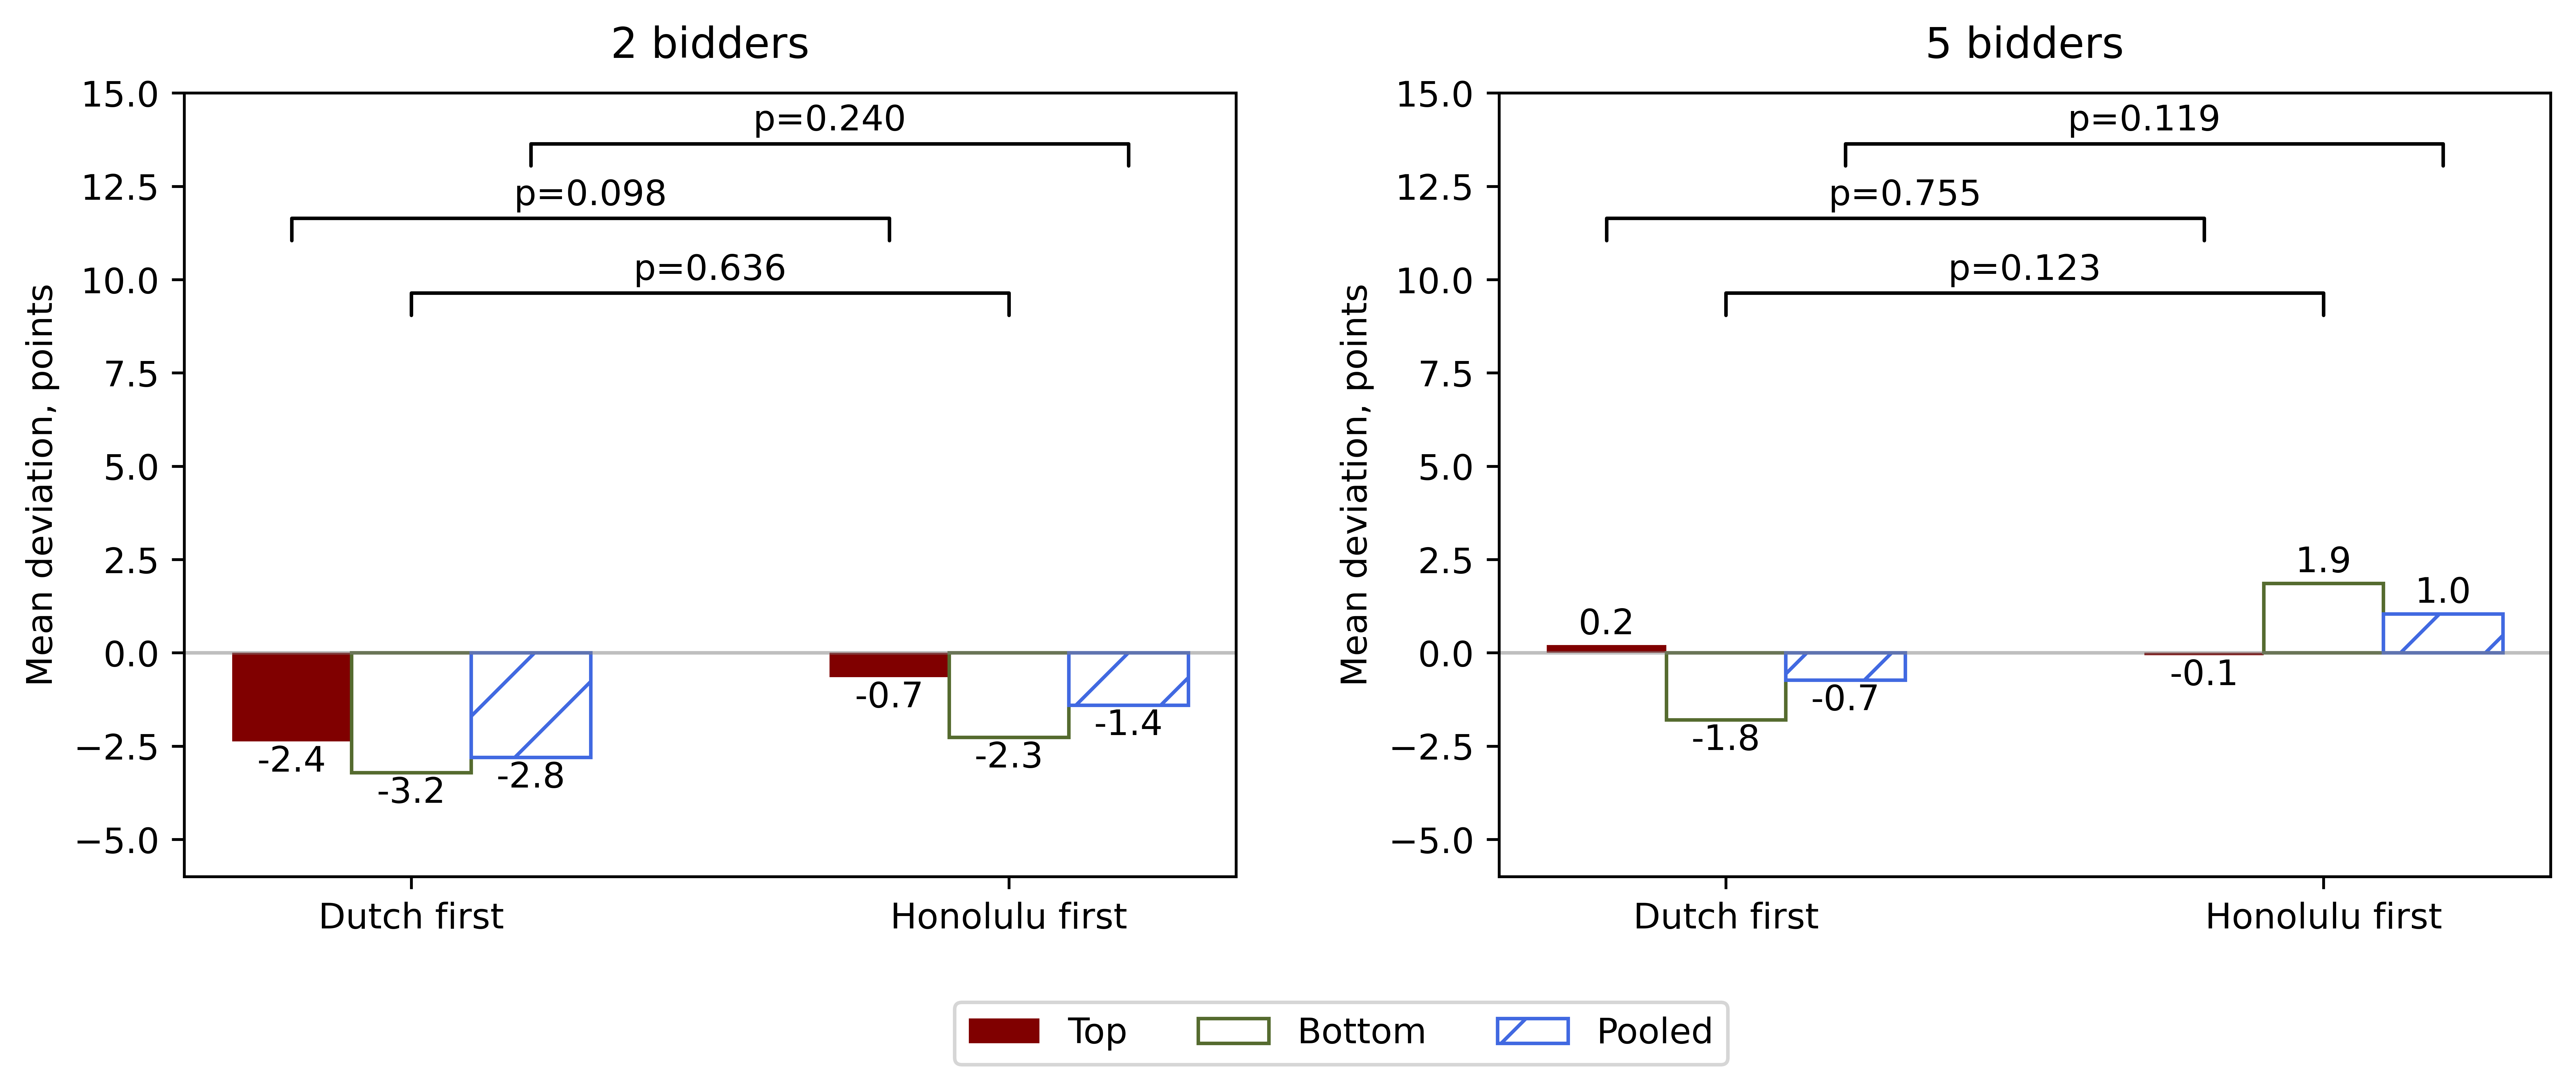

In [49]:
plt.figure(figsize=(12, 4), dpi=800)
plt.subplots_adjust(wspace=0.25, hspace=0.5)
plt.subplot(121)
plotDstage(2)
plt.subplot(122)
plotDstage(5)
plt.legend(ncol=3, loc="center", bbox_to_anchor=(-0.15, -0.2), fontsize="medium")

plt.savefig("FigI2_honolulu_bid_deviations_by_sequence_pyplot.png", bbox_inches="tight", format="png")

In [64]:
# dutch final price deviations

def dutchFinalDeviation(n, dfirst):
   
    tmp = df_d[(df_d["session.config.name"].str.contains(str(n) + "_"))]# & (df_d["session.config.discount_b"] == b)]
    if (dfirst == "D1") or (dfirst == "D2"):
        tmp = tmp[tmp["session.config.name"].str.contains(dfirst)]
    cols = [
        "subsession.round_number", "group.id_in_subsession",
        "group.dutch_final_price", "predict.group.dutch_final_price"
    ]
    tmp = tmp[cols]

    act = tmp["group.dutch_final_price"]
    pre = tmp["predict.group.dutch_final_price"]

    return np.mean(act) - np.mean(pre)

In [65]:
def plotDFinal(n):

    x = np.array([1, 2])
    wd = 0.3
    ybot = -6
    ytop = 11
    y1 = []
    for dfirst in ["D1", "D2"]:
        tmp1 = dutchFinalDeviation(n, dfirst)
        y1.append(tmp1)
    plt.bar(x, y1, width=wd, edgecolor="royalblue", fill=False, hatch="/", label="Pooled")
    plt.axhline(0, color="grey", linewidth=1, alpha=0.5)

    for a, b in zip(x, y1):
        if b >= 0:
            plt.text(a, b + 0.3, "%.1f" % b, ha="center", color="black", fontsize="medium")
        else:
            plt.text(a, b - 0.8, "%.1f" % b, ha="center", color="black", fontsize="medium")

    props = dict(
        connectionstyle = "bar, armA=0, armB=0, fraction=0.04",
        arrowstyle = "-",
        shrinkA = 0.5,
        shrinkB = 0.5,
        linewidth = 1,
    )
    p = 0.365 if n == 2 else 0.753
    plt.annotate("", (x[0], ytop - 2), (x[1], ytop - 2), arrowprops=props)
    plt.annotate("p=%.3f" % p, ((x[0] + x[1]) / 2, ytop - 1), ha="center", fontsize="medium")

    plt.xlim(0.5, 2.5)
    plt.ylim(ybot, ytop)
    plt.xticks(x, ["Dutch first", "Honolulu first"])
    plt.ylabel("Mean deviation, points")

    # plt.annotate("2 bidders", (1.5, ybot), (1.5, ybot-2.5), ha="center", fontsize="medium")
    # plt.annotate("5 bidders", (3.5, ybot), (3.5, ybot-2.5), ha="center", fontsize="medium")
    # plt.legend(ncol=2, loc="center", bbox_to_anchor=(0.5, -0.25))
    plt.title("%d bidders" % (n), pad=10, fontsize="large")

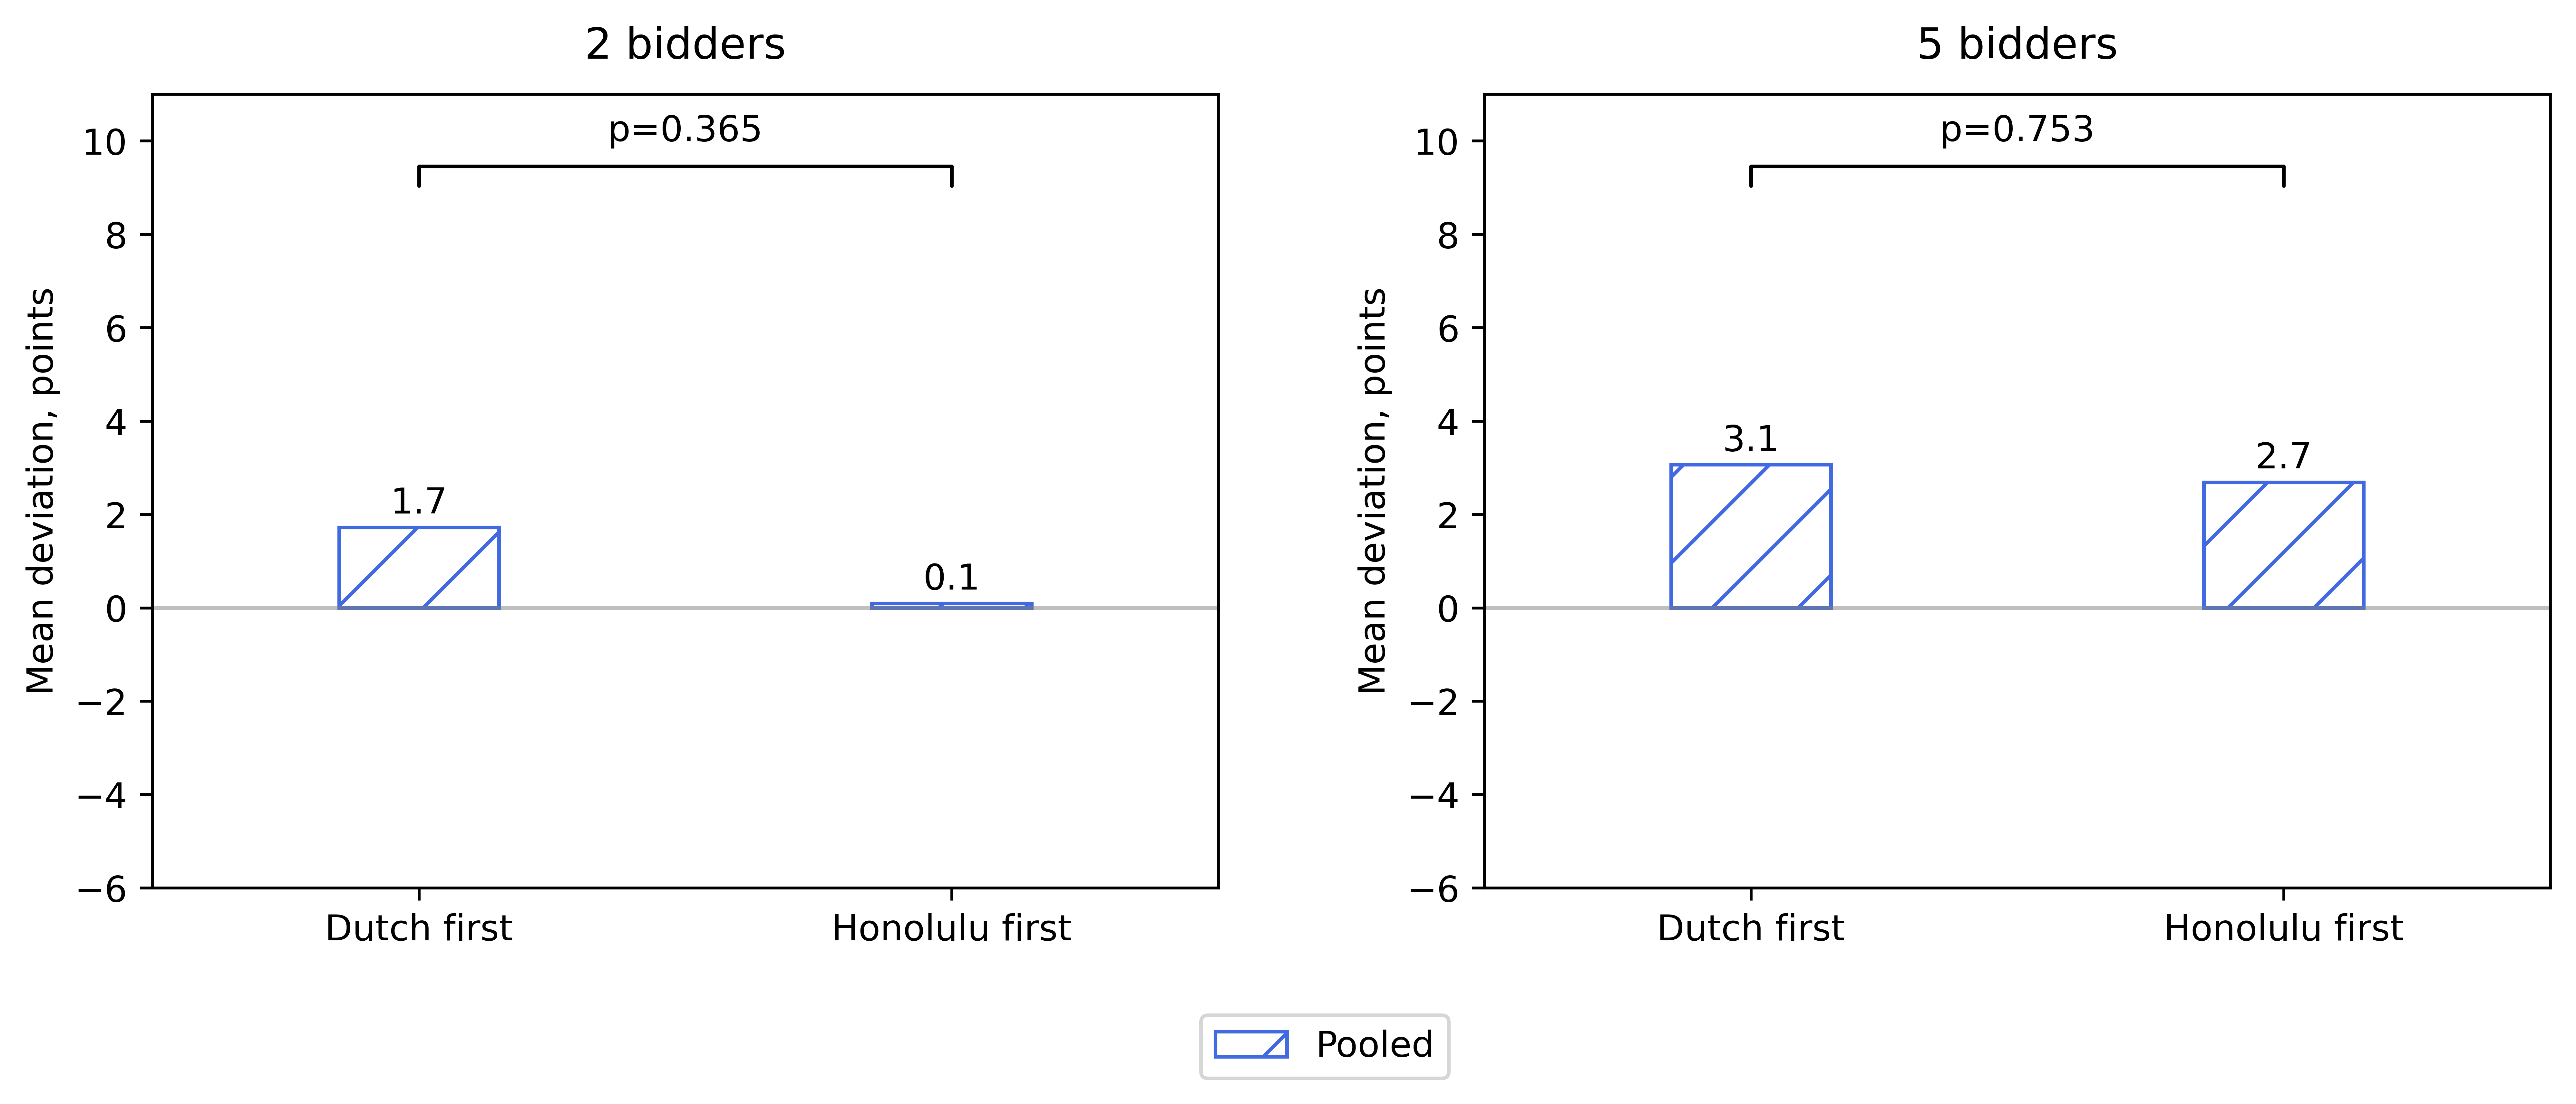

In [66]:
plt.figure(figsize=(12, 4), dpi=800)
plt.subplots_adjust(wspace=0.25, hspace=0.5)
plt.subplot(121)
plotDFinal(2)
plt.subplot(122)
plotDFinal(5)
plt.legend(ncol=1, loc="center", bbox_to_anchor=(-0.15, -0.2), fontsize="medium")

plt.savefig("FigI3_dutch_final_price_deviations_by_sequence_pyplot.png", bbox_inches="tight", format="png")

In [67]:
# honolulu final price deviations

def honoluluFinalDeviation(n, dfirst):
   
    tmp = df_h[(df_h["session.config.name"].str.contains(str(n) + "_"))]# & (df_h["session.config.discount_b"] == b)]
    if (dfirst == "D1") or (dfirst == "D2"):
        tmp = tmp[tmp["session.config.name"].str.contains(dfirst)]
    cols = [
        "subsession.round_number", "group.id_in_subsession",
        "group.final_price", "predict.group.final_price"
    ]
    tmp = tmp[cols].drop_duplicates()

    act = tmp["group.final_price"]
    pre = tmp["predict.group.final_price"]

    return np.mean(act) - np.mean(pre)

In [68]:
def plotHFinal(n):

    x = np.array([1, 2])
    wd = 0.3
    ybot = -6
    ytop = 11
    y1 = []
    for dfirst in ["D1", "D2"]:
        tmp1 = honoluluFinalDeviation(n, dfirst)
        y1.append(tmp1)
    plt.bar(x, y1, width=wd, edgecolor="royalblue", fill=False, hatch="/", label="Pooled")
    plt.axhline(0, color="grey", linewidth=1, alpha=0.5)

    for a, b in zip(x, y1):
        if b >= 0:
            plt.text(a, b + 0.3, "%.1f" % b, ha="center", color="black", fontsize="medium")
        else:
            plt.text(a, b - 0.8, "%.1f" % b, ha="center", color="black", fontsize="medium")

    props = dict(
        connectionstyle = "bar, armA=0, armB=0, fraction=0.04",
        arrowstyle = "-",
        shrinkA = 0.5,
        shrinkB = 0.5,
        linewidth = 1,
    )
    p = 0.640 if n == 2 else 0.197
    plt.annotate("", (x[0], ytop - 2), (x[1], ytop - 2), arrowprops=props)
    plt.annotate("p=%.3f" % p, ((x[0] + x[1]) / 2, ytop - 1), ha="center", fontsize="medium")

    plt.xlim(0.5, 2.5)
    plt.ylim(ybot, ytop)
    plt.xticks(x, ["Dutch first", "Honolulu first"])
    plt.ylabel("Mean deviation, points")

    # plt.annotate("2 bidders", (1.5, ybot), (1.5, ybot-2.5), ha="center", fontsize="medium")
    # plt.annotate("5 bidders", (3.5, ybot), (3.5, ybot-2.5), ha="center", fontsize="medium")
    # plt.legend(ncol=2, loc="center", bbox_to_anchor=(0.5, -0.25))
    plt.title("%d bidders" % (n), pad=10, fontsize="large")

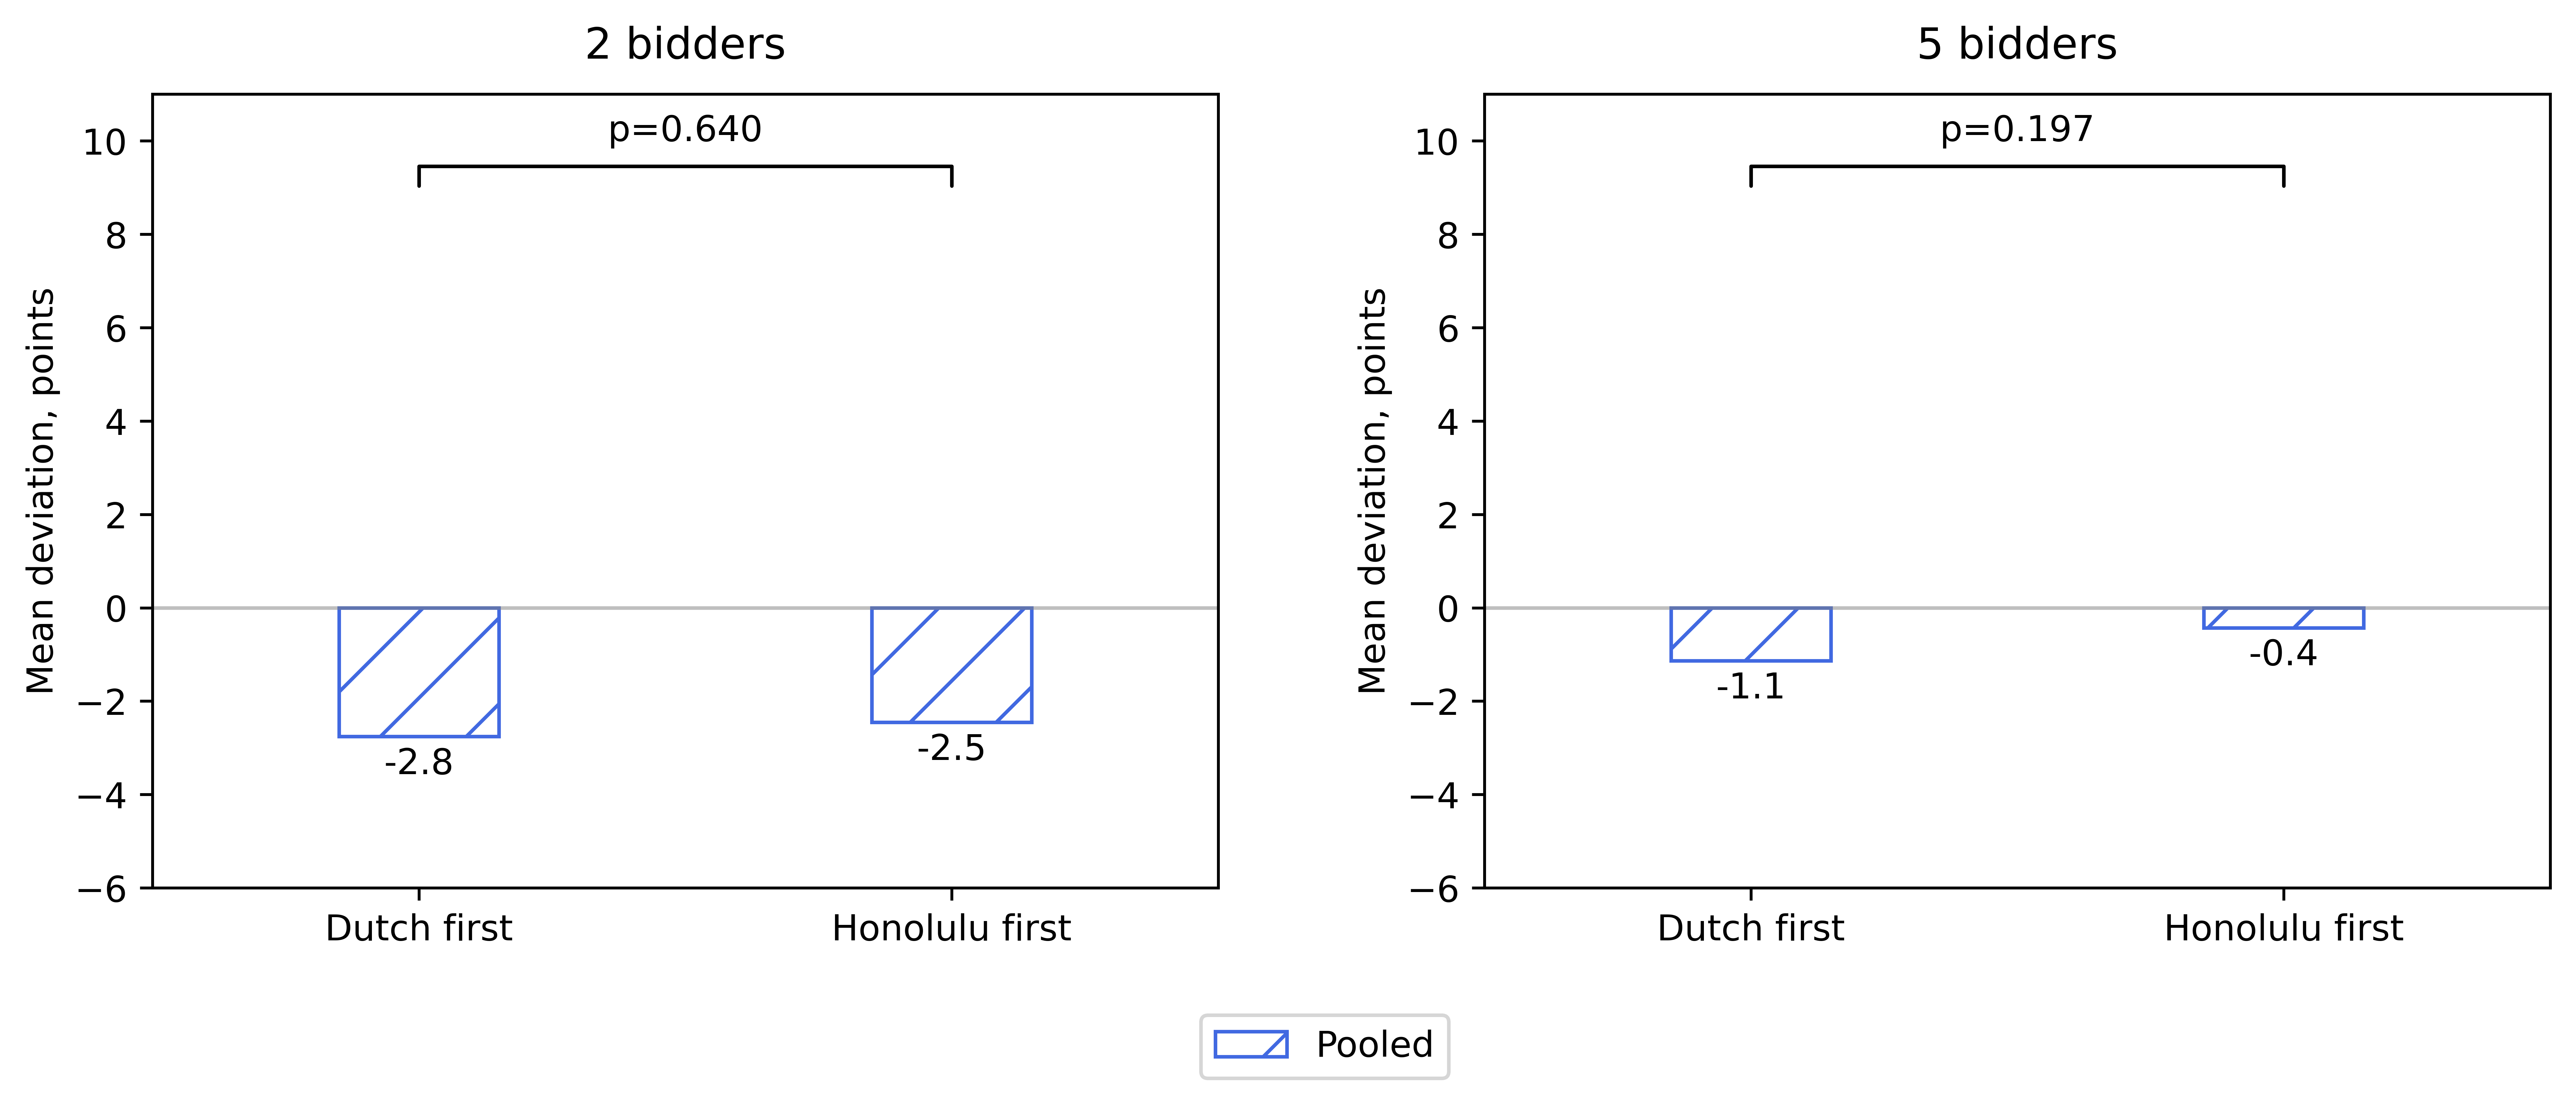

In [69]:
plt.figure(figsize=(12, 4), dpi=800)
plt.subplots_adjust(wspace=0.25, hspace=0.5)
plt.subplot(121)
plotHFinal(2)
plt.subplot(122)
plotHFinal(5)
plt.legend(ncol=1, loc="center", bbox_to_anchor=(-0.15, -0.2), fontsize="medium")

plt.savefig("FigI4_honolulu_final_price_deviations_by_sequence_pyplot.png", bbox_inches="tight", format="png")

### carryover effects for top and bottom earners (zero-cost)

In [62]:
# dutch auction bid deviations between top and bottom earners

def dutchDeviation(n, b, dfirst):

    print(["DA-all", np.mean(df_d[df_d["player.is_dutch_winner"] == 1]["group.dutch_final_price"]) - np.mean(df_d[df_d["player.is_dutch_winner"] == 1]["predict0.player.bid"])])

    if (dfirst == "D1") or (dfirst == "D2"):
        tmp = df_d[(df_d["session.config.name"].str.contains(str(n) + "_")) & (df_d["session.config.discount_b"] == b) & (df_d["session.config.name"].str.contains(dfirst))]
    else:
        tmp = df_d[(df_d["session.config.name"].str.contains(str(n) + "_")) & (df_d["session.config.discount_b"] == b)]
    qlist = tmp["paydiff_pct"].unique()
    tmp = tmp[tmp["player.is_dutch_winner"] == 1]

    # drop outliers with 1/3 or more bids that bid > value + 2
    # plist = tmp["participant.code"].unique()
    # droplist = []
    # for p in plist:
    #     n_all = len(tmp[tmp["participant.code"] == p])
    #     n_sd = len(tmp[(tmp["participant.code"] == p) & (tmp["player.item_value"] + 2 < tmp["group.dutch_final_price"])])
    #     if (n_sd / n_all >= 1 / 3):
    #         droplist.append(p)
    # tmp = tmp[~tmp["participant.code"].isin(droplist)]
    # print(droplist)

    tmp_top = tmp[(tmp["paydiff_pct"] > np.quantile(qlist, 0.5)) & (tmp["paydiff_pct"] <= np.quantile(qlist, 1))]
    tmp_bot = tmp[(tmp["paydiff_pct"] >= np.quantile(qlist, 0)) & (tmp["paydiff_pct"] <= np.quantile(qlist, 0.5))]

    act_top = tmp_top["group.dutch_final_price"]
    pre_top = tmp_top["predict0.player.bid"]
    act_bot = tmp_bot["group.dutch_final_price"]
    pre_bot = tmp_bot["predict0.player.bid"]

    print([n, b, "DA", np.mean(tmp["group.dutch_final_price"]) - np.mean(tmp["predict0.player.bid"])])

    return np.mean(act_top) - np.mean(pre_top), np.mean(act_bot) - np.mean(pre_bot)

In [63]:
def plotDbid(dfirst):

    x = np.array([1, 2, 3, 4])
    wd = 0.3
    ybot = -7
    ytop = 27
    y1 = []
    y2 = []
    for n in [2, 5]:
        for b in [0.019, 0.009]:
            tmp1, tmp2 = dutchDeviation(n, b, dfirst)
            y1.append(tmp1)
            y2.append(tmp2)
    plt.bar(x - 0.5 * wd, y1, width=wd, color="maroon", label="Top")
    plt.bar(x + 0.5 * wd, y2, width=wd, edgecolor="darkolivegreen", fill=False, label="Bottom")
    plt.axhline(0, color="grey", linewidth=1, alpha=0.5)

    for a, b in zip(x, y1):
        if b >= 0:
            plt.text(a - 0.5 * wd, b + 0.3, "%.1f" % b, ha="center", color="black", fontsize="medium")
        else:
            plt.text(a - 0.5 * wd, b - 0.8, "%.1f" % b, ha="center", color="black", fontsize="medium")
    for a, b in zip(x, y2):
        if b >= 0:
            plt.text(a + 0.5 * wd, b + 0.3, "%.1f" % b, ha="center", color="black", fontsize="medium")
        else:
            plt.text(a + 0.5 * wd, b - 0.8, "%.1f" % b, ha="center", color="black", fontsize="medium")

    # props = dict(
    #     connectionstyle = "bar, armA=0, armB=0, fraction=0.08",
    #     arrowstyle = "-",
    #     shrinkA = 0.5,
    #     shrinkB = 0.5,
    #     linewidth = 1,
    # )
    # p = [0.053, 0.027, 0.000, 0.000]
    # for i in range(len(x)):
    #     plt.annotate("", (x[i] - 0.5 * wd, ytop - 2), (x[i] + 0.5 * wd, ytop - 2), arrowprops=props)
    #     plt.annotate("p=%.3f" % p[i], (x[i], ytop - 1.5), ha="center", fontsize="medium")

    plt.ylim(ybot, ytop)
    plt.xticks(x, ["High", "Low", "High", "Low"])
    plt.ylabel("Mean deviation, points")

    plt.annotate("2 bidders", (1.5, ybot), (1.5, ybot-2.5), ha="center", fontsize="medium")
    plt.annotate("5 bidders", (3.5, ybot), (3.5, ybot-2.5), ha="center", fontsize="medium")
    # plt.legend(ncol=2, loc="center", bbox_to_anchor=(0.5, -0.25))
    plt.title("Dutch auction", pad=10, fontsize="large")

In [64]:
# dutch stage bid deviations between top and bottom earners

def dutchStageDeviation(n, b, dfirst):

    print(["HA-all", np.mean(df_h[df_h["player.is_dutch_winner"] == 1]["group.dutch_final_price"]) - np.mean(df_h[df_h["player.is_dutch_winner"] == 1]["predict0.player.optimal_dutch_bid"])])

    if (dfirst == "D1") or (dfirst == "D2"):
        tmp = df_h[(df_h["session.config.name"].str.contains(str(n) + "_")) & (df_h["session.config.discount_b"] == b) & (df_h["session.config.name"].str.contains(dfirst))]
    else:
        tmp = df_h[(df_h["session.config.name"].str.contains(str(n) + "_")) & (df_h["session.config.discount_b"] == b)]
    qlist = tmp["paydiff_pct"].unique()
    tmp = tmp[tmp["player.is_dutch_winner"] == 1]

    # drop outliers with 1/3 or more bids that bid > value + 2
    # plist = tmp["participant.code"].unique()
    # droplist = []
    # for p in plist:
    #     n_all = len(tmp[tmp["participant.code"] == p])
    #     n_sd = len(tmp[(tmp["participant.code"] == p) & (tmp["player.item_value"] + 2 < tmp["group.dutch_final_price"])])
    #     if (n_sd / n_all >= 1 / 3):
    #         droplist.append(p)
    # tmp = tmp[~tmp["participant.code"].isin(droplist)]
    # print(droplist)

    tmp_top = tmp[(tmp["paydiff_pct"] > np.quantile(qlist, 0.5)) & (tmp["paydiff_pct"] <= np.quantile(qlist, 1))]
    tmp_bot = tmp[(tmp["paydiff_pct"] >= np.quantile(qlist, 0)) & (tmp["paydiff_pct"] <= np.quantile(qlist, 0.5))]

    act_top = tmp_top["group.dutch_final_price"]
    pre_top = tmp_top["predict0.player.optimal_dutch_bid"]
    act_bot = tmp_bot["group.dutch_final_price"]
    pre_bot = tmp_bot["predict0.player.optimal_dutch_bid"]

    print([n, b, "HA", np.mean(tmp["group.dutch_final_price"]) - np.mean(tmp["predict0.player.optimal_dutch_bid"])])
    
    return np.mean(act_top) - np.mean(pre_top), np.mean(act_bot) - np.mean(pre_bot)

In [65]:
def plotDstage(dfirst):

    x = np.array([1, 2, 3, 4])
    wd = 0.3
    ybot = -7
    ytop = 27
    y1 = []
    y2 = []
    for n in [2, 5]:
        for b in [0.019, 0.009]:
            tmp1, tmp2 = dutchStageDeviation(n, b, dfirst)
            y1.append(tmp1)
            y2.append(tmp2)
    plt.bar(x - 0.5 * wd, y1, width=wd, color="maroon", label="Top")
    plt.bar(x + 0.5 * wd, y2, width=wd, edgecolor="darkolivegreen", fill=False, label="Bottom")
    plt.axhline(0, color="grey", linewidth=1, alpha=0.5)

    for a, b in zip(x, y1):
        if b >= 0:
            plt.text(a - 0.5 * wd, b + 0.3, "%.1f" % b, ha="center", color="black", fontsize="medium")
        else:
            plt.text(a - 0.5 * wd, b - 0.8, "%.1f" % b, ha="center", color="black", fontsize="medium")
    for a, b in zip(x, y2):
        if b >= 0:
            plt.text(a + 0.5 * wd, b + 0.3, "%.1f" % b, ha="center", color="black", fontsize="medium")
        else:
            plt.text(a + 0.5 * wd, b - 0.8, "%.1f" % b, ha="center", color="black", fontsize="medium")

    # props = dict(
    #     connectionstyle = "bar, armA=0, armB=0, fraction=0.08",
    #     arrowstyle = "-",
    #     shrinkA = 0.5,
    #     shrinkB = 0.5,
    #     linewidth = 1,
    # )
    # p = [0.009, 0.954, 0.718, 0.436] # [0.000, 0.954, 0.611, 0.436]
    # for i in range(len(x)):
    #     plt.annotate("", (x[i] - 0.5 * wd, ytop - 2), (x[i] + 0.5 * wd, ytop - 2), arrowprops=props)
    #     plt.annotate("p=%.3f" % p[i], (x[i], ytop - 1.5), ha="center", fontsize="medium")

    plt.ylim(ybot, ytop)
    plt.xticks(x, ["High", "Low", "High", "Low"])
    plt.ylabel("Mean deviation, points")

    plt.annotate("2 bidders", (1.5, ybot), (1.5, ybot-2.5), ha="center", fontsize="medium")
    plt.annotate("5 bidders", (3.5, ybot), (3.5, ybot-2.5), ha="center", fontsize="medium")
    # plt.legend(ncol=2, loc="center", bbox_to_anchor=(0.5, -0.25))
    plt.title("Dutch stage of Honolulu-Sydney auction", pad=10, fontsize="large")

['DA-all', 4.8545537340619305]
[2, 0.019, 'DA', 4.727401129943502]
['DA-all', 4.8545537340619305]
[2, 0.009, 'DA', 5.180473372781066]
['DA-all', 4.8545537340619305]
[5, 0.019, 'DA', 3.624761904761911]
['DA-all', 4.8545537340619305]
[5, 0.009, 'DA', 5.839795918367347]
['HA-all', 13.346628679962013]
[2, 0.019, 'HA', 9.7125748502994]
['HA-all', 13.346628679962013]
[2, 0.009, 'HA', 4.651757188498403]
['HA-all', 13.346628679962013]
[5, 0.019, 'HA', 23.87142857142857]
['HA-all', 13.346628679962013]
[5, 0.009, 'HA', 22.147959183673468]


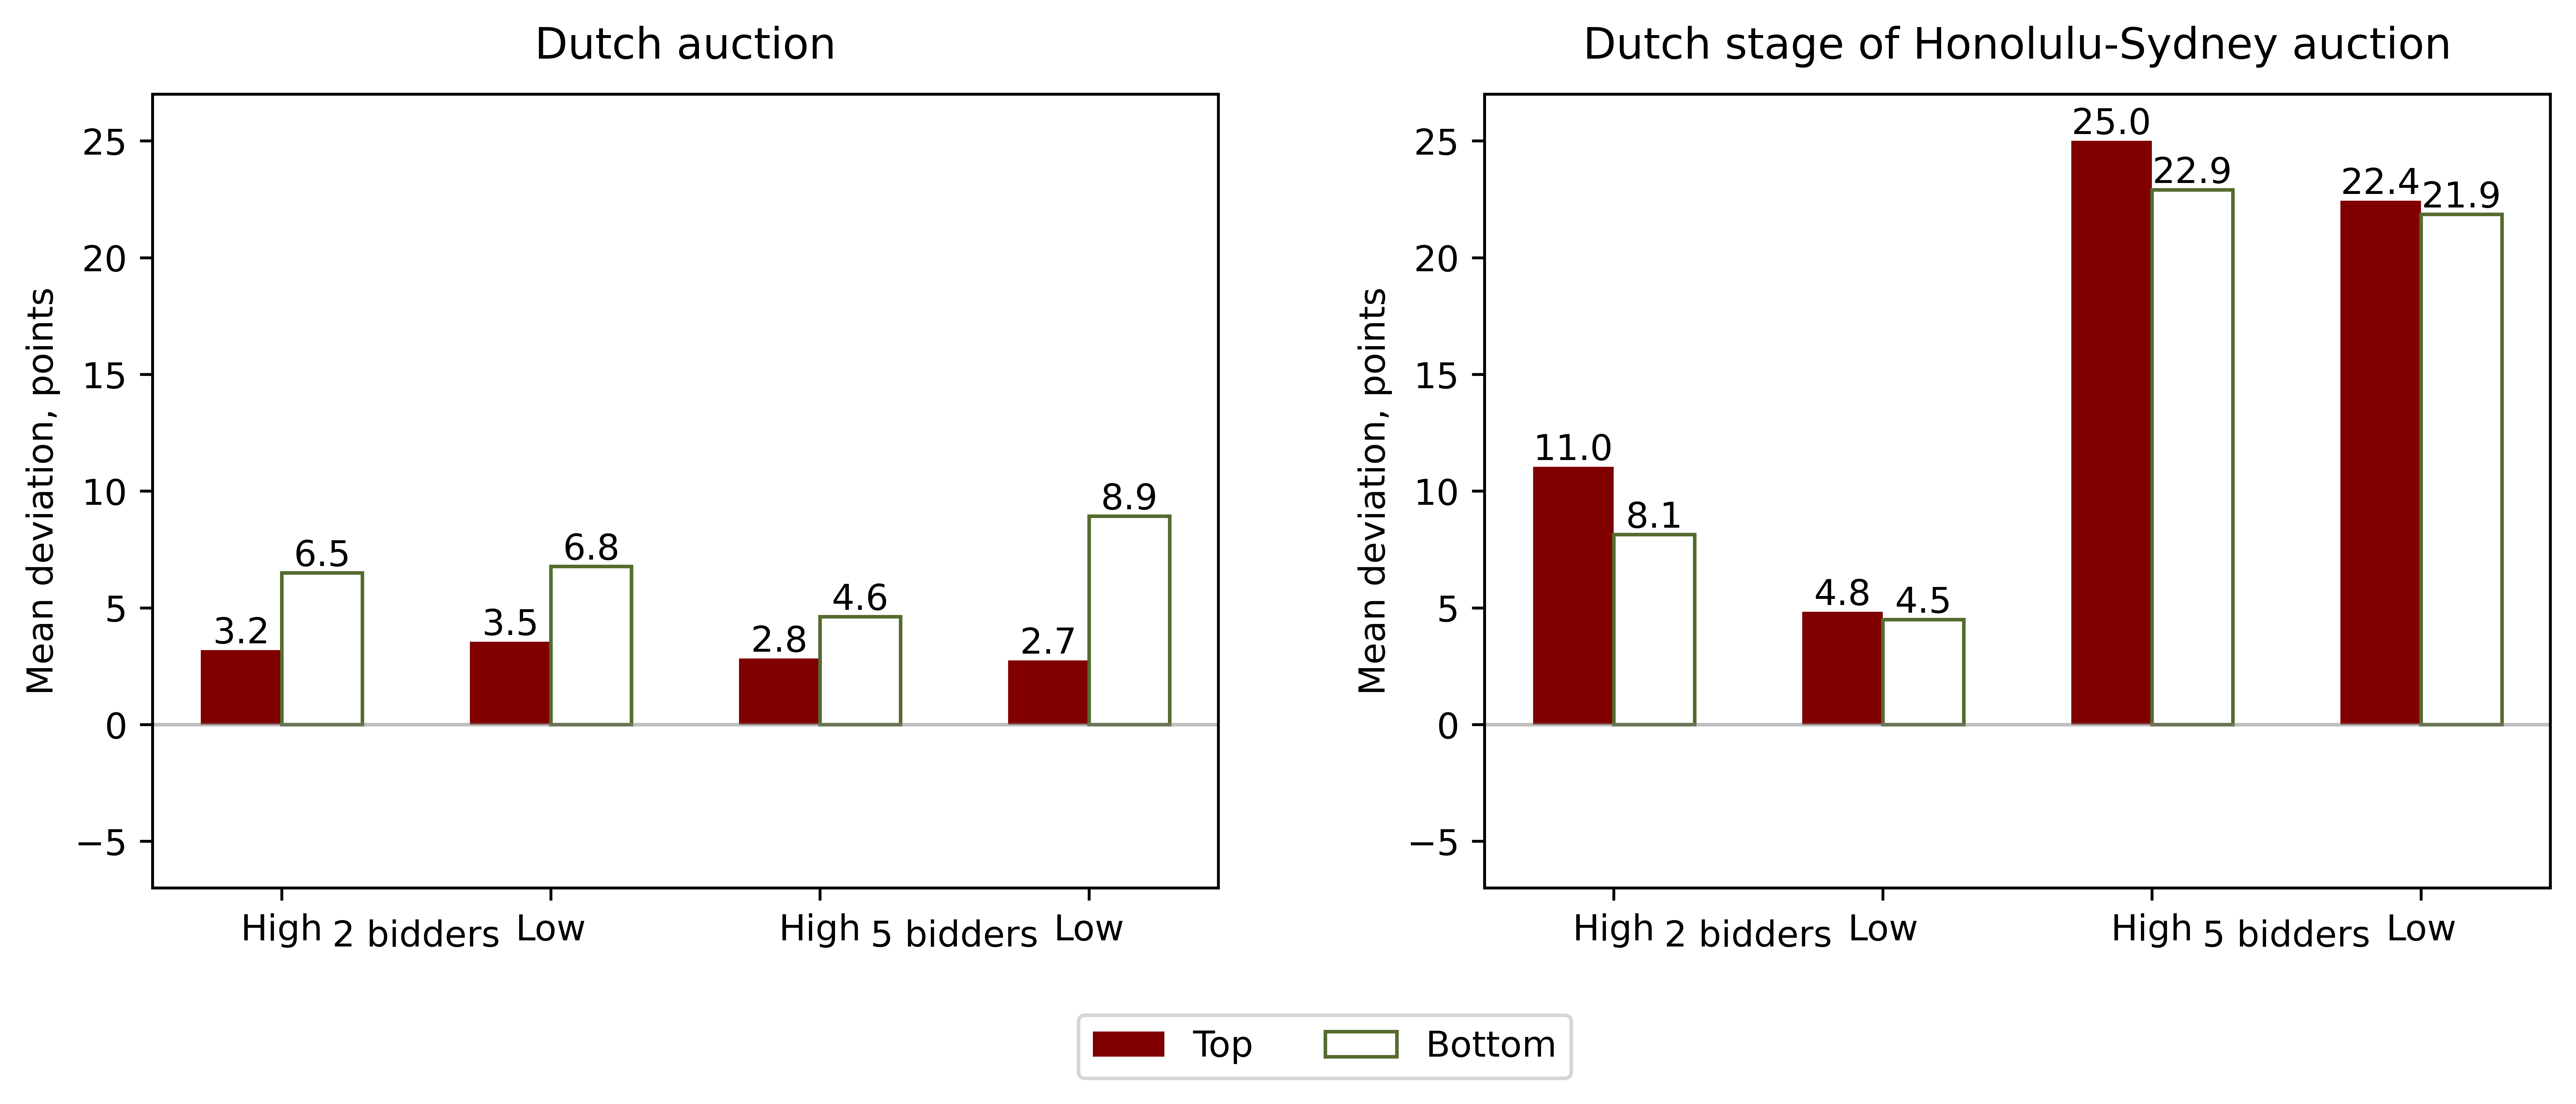

In [66]:
plt.figure(figsize=(12, 4), dpi=800)
plt.subplots_adjust(wspace=0.25, hspace=0.5)
plt.subplot(121)
plotDbid("D")
plt.subplot(122)
plotDstage("D")
plt.legend(ncol=2, loc="center", bbox_to_anchor=(-0.15, -0.2), fontsize="medium")

plt.savefig("dutch_bid_deviations_pyplot.png", bbox_inches="tight", format="png")